In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [8]:
df = pd.read_csv('wine_data.csv',header=None,usecols=[0,1,2])
df.columns=['Class label', 'Alcohol', 'Malic acid']

In [9]:
df.sample(5)

,Class label,Alcohol,Malic acid
81,2,12.72,1.81
29,1,14.02,1.68
87,2,11.65,1.67
130,3,12.86,1.35
5,1,14.20,1.76


In [10]:
df.describe()

,Class label,Alcohol,Malic acid
count,178.000000,178.000000,178.000000
mean,1.938202,13.000618,2.336348
std,0.775035,0.811827,1.117146
min,1.000000,11.030000,0.740000
25%,1.000000,12.362500,1.602500
50%,2.000000,13.050000,1.865000
75%,3.000000,13.677500,3.082500
max,3.000000,14.830000,5.800000


In [11]:
df.shape

(178, 3)

<Axes: xlabel='Alcohol', ylabel='Density'>

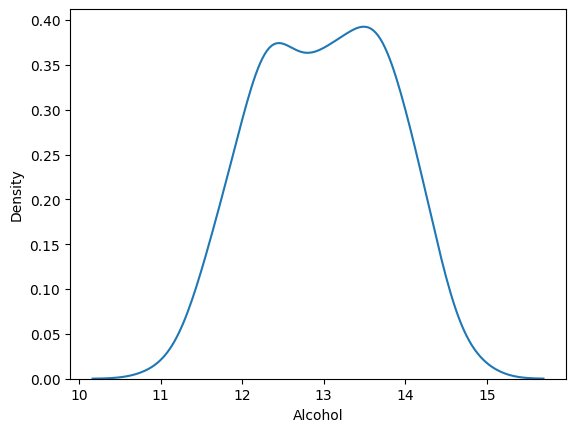

In [13]:
sns.kdeplot(df['Alcohol'])

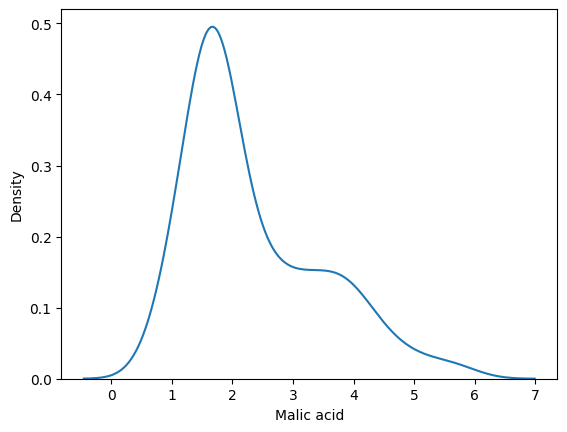

In [15]:
sns.kdeplot(df['Malic acid'])
plt.show()

In [16]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(df.drop('Class label', axis = 1), df['Class label'], test_size = 0.3, random_state= 0) 

In [39]:
x_train.shape, x_test.shape

((124, 2), (54, 2))

In [42]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

scaler.fit(x_train)
x_train_scaled = scaler.transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [43]:
x_train_scaled, x_train

(array([[0.72043011, 0.20378151],
        [0.31989247, 0.08403361],
        [0.60215054, 0.71218487],
        [0.57258065, 0.56302521],
        [0.76075269, 0.1302521 ],
        [0.48924731, 0.5       ],
        [0.75537634, 0.67857143],
        [0.61021505, 0.17436975],
        [0.54301075, 0.62394958],
        [0.39784946, 0.07352941],
        [0.33870968, 0.1092437 ],
        [0.46774194, 0.53361345],
        [0.5188172 , 0.53781513],
        [0.70967742, 0.07563025],
        [0.57258065, 0.30882353],
        [0.36021505, 0.0105042 ],
        [0.38709677, 0.13235294],
        [0.20967742, 0.25840336],
        [0.59408602, 0.64915966],
        [0.82526882, 0.26680672],
        [0.15591398, 0.09663866],
        [0.52688172, 0.16386555],
        [0.46774194, 0.31512605],
        [0.65860215, 0.16386555],
        [0.1155914 , 0.5987395 ],
        [0.27956989, 0.26680672],
        [0.21236559, 0.12184874],
        [0.65053763, 0.59033613],
        [0.31451613, 0.44957983],
        [0.543

In [44]:
x_train_scaled = pd.DataFrame(x_train_scaled, columns=x_train.columns)
x_test_scaled = pd.DataFrame(x_test_scaled, columns = x_test.columns)

In [45]:
np.round(x_train.describe(), 1)

,Alcohol,Malic acid
count,124.0,124.0
mean,13.0,2.4
std,0.8,1.1
min,11.0,0.9
25%,12.4,1.6
50%,13.0,1.9
75%,13.6,3.2
max,14.8,5.6


In [46]:
np.round(x_train_scaled.describe(), 1)

,Alcohol,Malic acid
count,124.0,124.0
mean,0.5,0.3
std,0.2,0.2
min,0.0,0.0
25%,0.4,0.2
50%,0.5,0.2
75%,0.7,0.5
max,1.0,1.0


In [47]:
y_train.shape, x_test_scaled.shape


((124,), (54, 2))

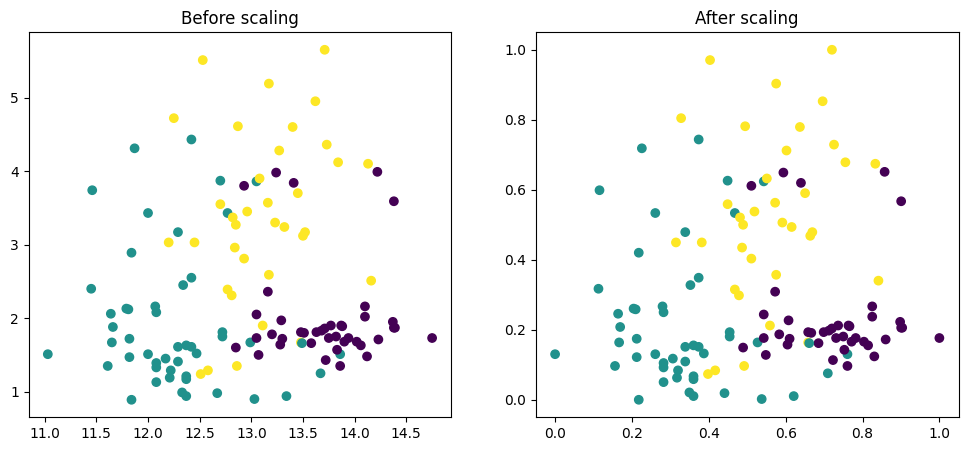

In [48]:
fig, (ax1, ax2) = plt.subplots(ncols = 2, figsize = (12,5))

ax1.scatter(x_train['Alcohol'], x_train['Malic acid'], c=y_train)
ax1.set_title("Before scaling")

ax2.scatter(x_train_scaled['Alcohol'], x_train_scaled['Malic acid'],c = y_train)
ax2.set_title('After scaling')

plt.show()